In [1]:
#Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#INICIO

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.tree import plot_tree
from sklearn.metrics import roc_curve, auc

import joblib

In [4]:
#Configurando o pandas para exibir todas as linhas, colunas e o conteúdo completo das células
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [5]:
#Importando a base de dados
dados = pd.read_csv('C:\\Users\\luisb\\Desktop\\BASE_DE_DADOS\\2feats.csv')

In [6]:
dados.head()

,goout,absences,target
0,4,6,0
1,3,4,0
2,2,10,0
3,2,2,0
4,2,4,0


In [16]:
#Separação em variavei preditivas e variável resposta
X = dados[['goout', 'absences']]
Y = dados['target']

#Separação em treino e teste
X_TREINO, X_TESTE, Y_TREINO, Y_TESTE = train_test_split(X, Y, test_size=0.3, random_state=42)

#Busca no espaço de hiperparâmetros
max_depth_values = [2, 3, 4, 5, 6, 7, 8, 9, 10] #Profundidade máxima da árvore
f1s = np.array([], dtype='float64') #Lista para armazenar os F1-scores correspondentes a cada valor de max_depth

for max_depth_values in max_depth_values:
    dt = DecisionTreeClassifier(max_depth=max_depth_values, random_state=123) #Criando o modelo de árvore de decisão
    dt.fit(X_TREINO, Y_TREINO) #Treinando o modelo
    Y_PRED = dt.predict(X_TESTE) #Fazendo previsões no conjunto de teste
    f1 = f1_score(Y_TESTE, Y_PRED) #Calculando o F1-score
    f1s = np.append(f1s, f1) #Armazenando o F1-score na lista correspondente ao valor de max_depth
    print(f'Max Depth: {max_depth_values}, F1 Score: {f1}') #Exibindo o valor de max_depth e o F1-score correspondente

Max Depth: 2, F1 Score: 0.4117647058823529
Max Depth: 3, F1 Score: 0.47368421052631576
Max Depth: 4, F1 Score: 0.4375
Max Depth: 5, F1 Score: 0.42424242424242425
Max Depth: 6, F1 Score: 0.45714285714285713
Max Depth: 7, F1 Score: 0.45714285714285713
Max Depth: 8, F1 Score: 0.45714285714285713
Max Depth: 9, F1 Score: 0.4117647058823529
Max Depth: 10, F1 Score: 0.45714285714285713


In [19]:
#best_max_depth = max_depth_values[np.argmax(f1s)] #Encontrando o valor de max_depth que obteve o melhor F1-score

dt = DecisionTreeClassifier(max_depth=3, random_state=42) #Criando o modelo de árvore de decisão com o melhor valor de max_depth
dt.fit(X_TREINO, Y_TREINO) #Treinando o modelo com o melhor valor de max_depth
Y_PRED = dt.predict(X_TESTE) #Fazendo previsões no conjunto de teste com o modelo otimizado

In [20]:
precision = precision_score(Y_TESTE, dt.predict(X_TESTE)) #Calculando a precisão
recall = recall_score(Y_TESTE, dt.predict(X_TESTE)) #Calculando o recall
print(f'Precision: {precision}, Recall: {recall}') #Exibindo a precisão e o recall do modelo otimizado

Precision: 0.6, Recall: 0.391304347826087


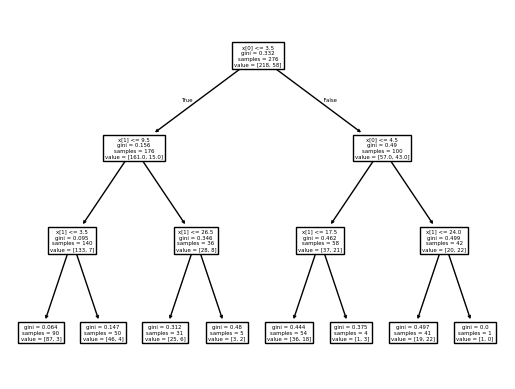

In [25]:
plot_tree(dt); #Visualizando a árvore de decisão otimizada

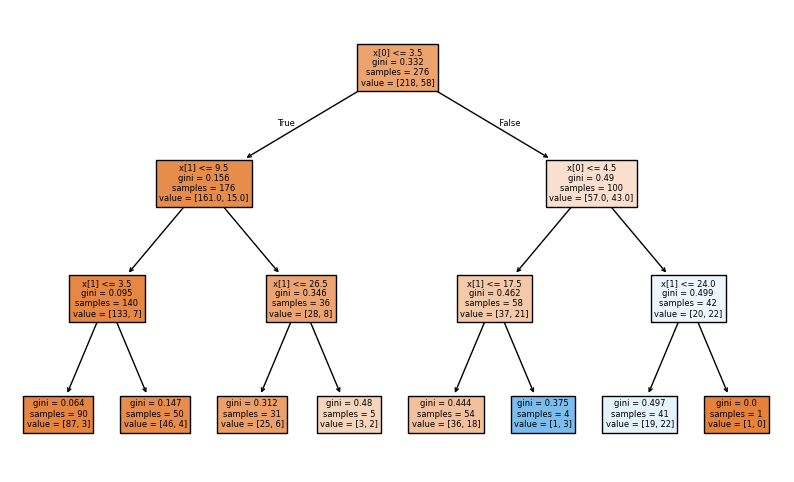

In [26]:
plt.figure(figsize=(10, 6))
ax = plt.subplot(1,1,1)
plot_tree(dt, filled=True, ax=ax)
plt.show()

In [ ]:
dt.predict_proba(X_TESTE) #Exibindo as probabilidades de cada classe para as previsões do modelo otimizado

In [ ]:
dt.predict_proba(X_TESTE)[:,1] #Exibindo apenas as probabilidades da classe positiva (classe 1) para as previsões do modelo otimizado

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True, False, False, False, False, False,
       False, False, False,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True,  True,  True, False, False, False, False, False,
       False, False, False,  True, False, False, False, False,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False,  True,
       False, False, False,  True, False, False,  True, False,  True,
       False,  True])

In [34]:
predict1 = dt.predict_proba(X_TESTE)[:,1] > 0.50 #Exibindo um array booleano indicando quais previsões do modelo otimizado têm probabilidade da classe positiva (classe 1) maior que 0.50
predict2 = dt.predict(X_TESTE)

predict1 == predict2

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])

In [ ]:
#encontrando o linear
ths = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9] #Lista de limiares para classificar as previsões do modelo otimizado

for th in ths:
    print(th, f1_score(Y_TESTE, dt.predict_proba(X_TESTE)[:,1] > th)) #Exibindo o limiar e o F1-score correspondente para cada limiar testado

0.1 0.4383561643835616
0.2 0.4838709677419355
0.3 0.4838709677419355
0.4 0.47368421052631576
0.5 0.47368421052631576
0.6 0.14814814814814814
0.7 0.14814814814814814
0.8 0.0
0.9 0.0


In [ ]:
#Curva ROC

In [ ]:
joblib.dump(dt, 'modelo_arvore_decisao.pkl') #Salvando o modelo otimizado em um arquivo .pkl para uso futuro       